# Cross-Attention Analysis & XAI

This notebook analyzes the Cross-Attention mechanism of the Multimodal Emotion Recognition model.
It covers:
1.  **Attention Map Visualization**: How text tokens align with audio frames.
2.  **Time-Text Alignment**: Correlating Pitch (Prosody) with Attention weights.
3.  **Modality Contribution Ratio (MCR)**: Quantifying the importance of Audio vs Text for each emotion.


In [1]:
import sys
import os
sys.path.append(os.path.abspath('src'))

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import parselmouth
from tqdm import tqdm

from dataset import IEMOCAPDataset
from model import MultimodalEmotionModel
from config import BATCH_SIZE, ID2EMOTION, EMOTIONS
from torch.utils.data import DataLoader
from xai.attention_viz import AttentionVisualizer
from xai.mcr_analysis import compute_mcr_simple

# Set style
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

## 1. Load Model and Data

In [2]:
# Device configuration
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

# Load Model
MODEL_PATH = '../models/best_model.pt'
if not os.path.exists(MODEL_PATH):
    MODEL_PATH = 'models/best_model.pt'

print(f"Loading model from {MODEL_PATH}...")
model = MultimodalEmotionModel().to(device)
checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model loaded successfully.")

# Load Test Data
print("Loading test data...")
test_ds = IEMOCAPDataset(split='test')
# Batch size 1 for individual analysis
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)
print(f"Loaded {len(test_ds)} test samples")

Using device: mps
Loading model from ../models/best_model.pt...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded successfully.
Loading test data...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'AbstractTTS/IEMOCAP' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading AbstractTTS/IEMOCAP...


Loaded 1376 samples for split 'test'
Loaded 1376 test samples


## 2. Cross-Attention Visualization (Figure 4.8)

We visualize the Cross-Attention weights to see which audio frames the model focuses on for each text token.
We select one representative sample for each emotion (ANG, HAP, NEU, SAD).


In [3]:
# Find representative samples for each emotion
target_emotions = ['ang', 'hap', 'neu', 'sad']
samples = {}

print("Searching for correct predictions for each emotion...")
with torch.no_grad():
    for idx, batch in enumerate(test_loader):
        if len(samples) >= 4:
            break
            
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        audio = batch['audio'].to(device)
        audio_mask = batch['audio_mask'].to(device)
        labels = batch['label'].to(device)
        
        # Forward
        outputs = model(input_ids, attention_mask, audio, audio_mask)
        pred = torch.argmax(outputs['logits'], dim=1).item()
        true_label = ID2EMOTION[labels.item()]
        pred_label = ID2EMOTION[pred]
        
        # Only take correct predictions
        if true_label == pred_label and true_label in target_emotions and true_label not in samples:
            samples[true_label] = {
                'id': idx,
                'input_ids': input_ids[0].cpu(),
                'attention_weights': outputs['attention_weights'].cpu(), # Store on CPU
                'audio_np': audio[0].cpu().numpy(),
                'true_label': true_label,
                'pred_label': pred_label
            }
            print(f"Found sample for {true_label} (ID: {idx})")

# Visualize Gallery
viz = AttentionVisualizer()
gallery_data = []

for emo in target_emotions:
    if emo in samples:
        s = samples[emo]
        gallery_data.append({
            'id': s['id'],
            'attention_weights': s['attention_weights'],
            'tokens': s['input_ids'],
            'true_label': s['true_label'].upper(),
            'pred_label': s['pred_label'].upper()
        })

os.makedirs('results', exist_ok=True)
viz.plot_attention_gallery(
    gallery_data, 
    save_path='results/cross_attention_heatmap.png',
    title='Cross-Attention Patterns by Emotion'
)
plt.show()

Searching for correct predictions for each emotion...


Found sample for hap (ID: 1)
Found sample for sad (ID: 2)
Found sample for neu (ID: 4)
Found sample for ang (ID: 5)


/Users/sangyub/Desktop/xai_Team_project/multimodal_xai/new_venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/sangyub/Desktop/xai_Team_project/multimodal_xai/new_venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/sangyub/Desktop/xai_Team_project/multimodal_xai/new_venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.draw()


/Users/sangyub/Desktop/xai_Team_project/multimodal_xai/src/xai/attention_viz.py:205: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/sangyub/Desktop/xai_Team_project/multimodal_xai/src/xai/attention_viz.py:209: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')


✅ Saved: results/cross_attention_heatmap.png


## 3. Time-Text Alignment Analysis

We overlay the **Pitch Contour** (F0) with the **Attention Profile** (sum of attention weights per time step).
hypothesis:
- **Anger**: High pitch segments should attract high attention.
- **Sadness**: Flat pitch, attention might be more distributed or focused on silence/pauses.


DEBUG: Attn shape raw: torch.Size([1, 128, 299])
DEBUG: Attn shape processed: torch.Size([128, 299])
DEBUG: Attn profile shape: (299,)
Saved alignment plot to results/alignment_ang.png


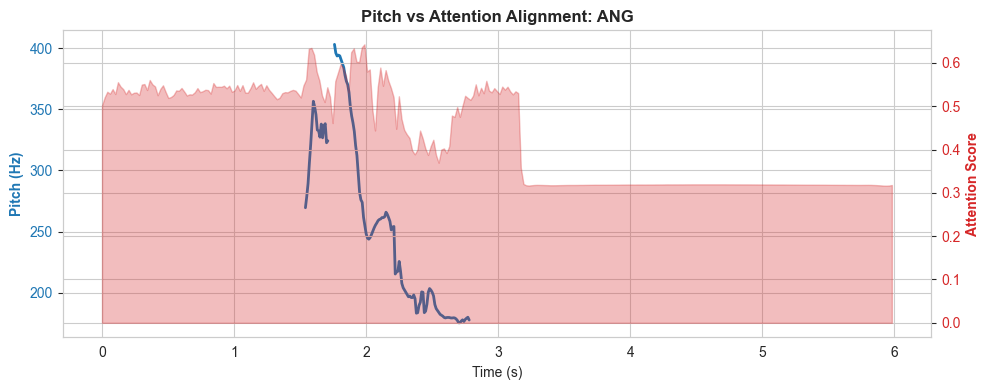

DEBUG: Attn shape raw: torch.Size([1, 128, 299])
DEBUG: Attn shape processed: torch.Size([128, 299])
DEBUG: Attn profile shape: (299,)
Saved alignment plot to results/alignment_sad.png


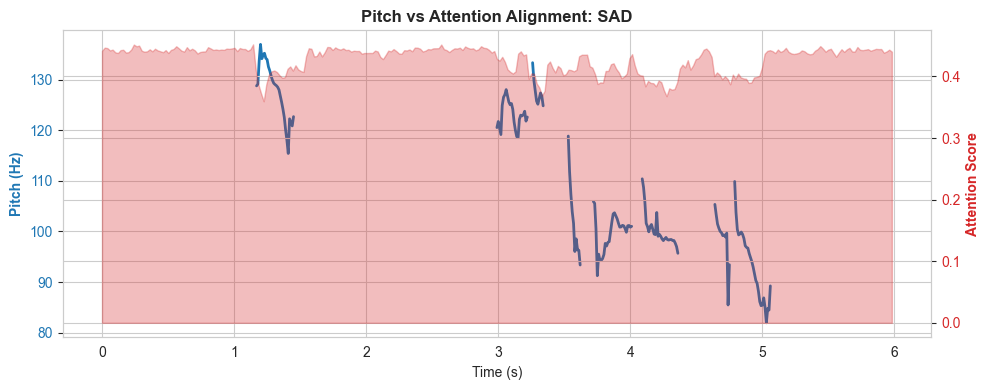

In [4]:
def extract_pitch(audio_np, sr=16000):
    try:
       snd = parselmouth.Sound(audio_np, sampling_frequency=sr)
       pitch = snd.to_pitch()
       pitch_values = pitch.selected_array['frequency']
       pitch_values[pitch_values==0] = np.nan # Remove unvoiced
       times = pitch.xs()
       return times, pitch_values
    except Exception as e:
       print(f"Pitch extraction failed: {e}")
       return np.array([]), np.array([])

def plot_pitch_vs_attention(sample, save_path=None):
    attn = sample['attention_weights'] # (1, heads, text, audio)
    print(f"DEBUG: Attn shape raw: {attn.shape}")
    
    # Squeeze batch dim if present
    if len(attn.shape) == 4:
        attn = attn[0] # (heads, text, audio)
    
    # Average over heads if present
    if len(attn.shape) == 3:
        attn = attn.mean(dim=0) # (text, audio)
        
    print(f"DEBUG: Attn shape processed: {attn.shape}")
    
    # Sum over text tokens to get attention profile per audio frame
    attn_profile = attn.sum(dim=0) # (audio)
    
    # Ensure it's numpy and 1D
    if torch.is_tensor(attn_profile):
        attn_profile = attn_profile.detach().cpu().numpy()
    attn_profile = np.squeeze(attn_profile)
    
    print(f"DEBUG: Attn profile shape: {attn_profile.shape}")
    
    audio_np = sample['audio_np']
    times, pitch = extract_pitch(audio_np)
    
    if len(times) == 0:
        print("Skipping pitch plot due to extraction error")
        return

    fig, ax1 = plt.subplots(figsize=(10, 4))
    
    color = 'tab:blue'
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Pitch (Hz)', color=color, fontweight='bold')
    ax1.plot(times, pitch, color=color, linewidth=2, label='Pitch (F0)')
    ax1.tick_params(axis='y', labelcolor=color)
    
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Attention Score', color=color, fontweight='bold')
    
    # interpolate attention profile to match pitch (optional) or just plot on its own time axis
    # Here we just map it to 0..duration
    attn_times = np.linspace(0, times[-1], len(attn_profile))
    
    try:
        ax2.fill_between(attn_times, 0, attn_profile, color=color, alpha=0.3, label='Attention')
    except Exception as e:
        print(f"Plotting error: {e}")
        # Fallback to plot
        ax2.plot(attn_times, attn_profile, color=color, alpha=0.3)
        
    ax2.tick_params(axis='y', labelcolor=color)
    
    plt.title(f"Pitch vs Attention Alignment: {sample['true_label'].upper()}", fontweight='bold')
    fig.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
        print(f"Saved alignment plot to {save_path}")
    plt.show()

# Plot for Anger and Sadness
if 'ang' in samples:
    plot_pitch_vs_attention(samples['ang'], save_path='results/alignment_ang.png')

if 'sad' in samples:
    plot_pitch_vs_attention(samples['sad'], save_path='results/alignment_sad.png')

## 4. Modality Contribution Ratio (MCR) Analysis

We quantify whether the model relies more on **Audio** or **Text** for each emotion.
MCR = Audio_Confidence / (Text_Confidence + Audio_Confidence).


In [5]:
# Run MCR Analysis
# Note: This might take a minute as it runs inference multiple times per sample
results, summary = compute_mcr_simple(model_path=MODEL_PATH, n_samples=200)

# The compute_mcr_simple function automatically saves 'results/mcr_distribution.png' and 'results/mcr_summary.csv'
# We just need to display the summary here
import pandas as pd
df_summary = pd.DataFrame(summary).T
print("MCR Summary:")
print(df_summary)

Using device: cpu

Loading test data...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'AbstractTTS/IEMOCAP' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading AbstractTTS/IEMOCAP...


Loaded 1376 samples for split 'test'
Loading model from ../models/best_model.pt...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

  Processed 140/200 samples...


  Processed 160/200 samples...


  Processed 180/200 samples...


  Processed 200/200 samples...

Completed MCR analysis for 200 samples

MCR STATISTICS PER EMOTION
Emotion    | Mean MCR   | Std      | n     | Interpretation
----------------------------------------------------------------------
ANG        |     0.546 |   0.133 | 32    | Balanced
SAD        |     0.790 |   0.207 | 55    | Audio Dominant
HAP        |     0.014 |   0.006 | 83    | Text Dominant
NEU        |     0.822 |   0.080 | 30    | Audio Dominant

✅ Saved: results/mcr_distribution.png
✅ Saved: results/mcr_summary.csv

STATISTICAL COMPARISON (T-TEST)
ANG vs SAD: t=-5.926, p=0.0000 ***
ANG vs HAP: t=35.880, p=0.0000 ***
ANG vs NEU: t=-9.657, p=0.0000 ***
SAD vs HAP: t=33.936, p=0.0000 ***
SAD vs NEU: t=-0.825, p=0.4118 ns
HAP vs NEU: t=-90.183, p=0.0000 ***

MCR ANALYSIS COMPLETE


MCR Summary:
         mean       std    median  n_samples
ang  0.545602  0.133424  0.531546       32.0
sad  0.789639  0.206546  0.860389       55.0
hap  0.014149  0.005925  0.012818       83.0
neu  0.822393  0.080322  0.845866       30.0
